In [ ]:
from pymatgen.ext.optimade import OptimadeRester
from pymatgen.analysis.dimensionality import get_dimensionality_gorai

opt = OptimadeRester(["alexandria"], timeout=None)

all_pt = opt.get_structures_with_filter(
    '(elements HAS "Pt") AND (nelements=1)'
)["alexandria"]

pt_structures = []

for structure in all_pt:

    # Keep only structures with < 25 sites
    if len(structure) >= 25:
        continue

    # Keep only 3D structures
    dim = get_dimensionality_gorai(structure, max_hkl=2)

    if dim != 3:
        continue

    pt_structures.append(structure)


print(type(all_pt))
print(all_pt.keys())
print(type(all_pt["data"][0]))

alexandria: 100%|██████████| 23/23 [00:00<00:00, 91.26it/s]


NameError: name 'structures' is not defined

In [1]:


import json
from pathlib import Path
from urllib.parse import urljoin

import requests
from pymatgen.core import Lattice, Structure
from pymatgen.ext.optimade import OptimadeRester


import json

from pymatgen.core import Structure


# ------------------------------------------------------------
# Load the supplied Pt dataset
# ------------------------------------------------------------

with open("omitted_20Pt_strucs.json", "r") as file:
    pt_data = json.load(file)


pt_ids = list(pt_data["structure"])

print("Number of Pt structures:", len(pt_ids))
print("Dataset fields:", list(pt_data))


# ------------------------------------------------------------
# Verify every Pt structure
# ------------------------------------------------------------

verification_errors = []
pt_structures = {}

for structure_id in pt_ids:

    structure = Structure.from_dict(
        pt_data["structure"][structure_id]
    )

    pt_structures[structure_id] = structure

    # Check pure Pt
    if structure.composition.chemical_system != "Pt":
        verification_errors.append(
            f"{structure_id}: not pure Pt"
        )

    # Check fewer than 25 sites
    if structure.num_sites >= 25:
        verification_errors.append(
            f"{structure_id}: has {structure.num_sites} sites"
        )

    # Check three-dimensional periodicity
    if tuple(structure.lattice.pbc) != (True, True, True):
        verification_errors.append(
            f"{structure_id}: pbc={structure.lattice.pbc}"
        )

    # Check stored n_sites
    if structure.num_sites != pt_data["n_sites"][structure_id]:
        verification_errors.append(
            f"{structure_id}: stored n_sites does not match structure"
        )


print("\nVerification errors:", len(verification_errors))

for error in verification_errors:
    print(error)

print("\nSite counts:")
print(sorted(structure.num_sites for structure in pt_structures.values()))

Number of Pt structures: 20
Dataset fields: ['structure', 'chemsys', 'n_sites', 'k_reuss', 'k_voigt', 'k_vrh']

Verification errors: 0

Site counts:
[1, 1, 1, 1, 2, 2, 2, 2, 3, 4, 4, 4, 5, 6, 7, 10, 12, 12, 16, 16]


In [ ]:
import json
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

standardized_pt_data = {"structure": {}, "chemsys": {}, "n_sites": {}, "k_reuss": {}, "k_voigt": {}, "k_vrh": {}}
standardization_failures = []

for sid, structure in pt_structures.items():
    try:
        analyzer = SpacegroupAnalyzer(structure, symprec=0.1, angle_tolerance=5)
        conv = analyzer.get_conventional_standard_structure()
        standardized_pt_data["structure"][sid] = conv.as_dict()
        standardized_pt_data["chemsys"][sid] = "Pt"                                #can be removed
        standardized_pt_data["n_sites"][sid] = conv.num_sites                      #can be removed
        standardized_pt_data["k_reuss"][sid] = pt_data["k_reuss"][sid]
        standardized_pt_data["k_voigt"][sid] = pt_data["k_voigt"][sid]
        standardized_pt_data["k_vrh"][sid] = pt_data["k_vrh"][sid]
        print(f"{sid}: {structure.num_sites} → {conv.num_sites} sites | space group {analyzer.get_space_group_symbol()}")
    except Exception as e:
        print(f"FAILED {sid}: {e}")

with open("standardized_20Pt_structures.json", "w", encoding="utf-8") as f:
    json.dump(standardized_pt_data, f, indent=2)

print("\nStandardized structures:", len(standardized_pt_data["structure"]))
print("Failures:", len(standardization_failures))
print("Saved as: standardized_20Pt_structures.json")

agm004404758: 4 → 4 sites | space group P6_3/mmc
agm004458604: 1 → 1 sites | space group Pm-3m
agm002180024: 2 → 2 sites | space group P6_3/mmc
agm004458612: 2 → 2 sites | space group P6/mmm
agm003277942: 1 → 2 sites | space group I4/mmm
agm004458601: 16 → 16 sites | space group Im-3m
agm002180025: 4 → 4 sites | space group P6_3/mmc
agm014162597: 4 → 12 sites | space group R-3m
agm003157154: 1 → 2 sites | space group Im-3m
agm004458602: 16 → 16 sites | space group I4/mmm
agm012338466: 7 → 21 sites | space group R-3m
agm004458610: 12 → 12 sites | space group Im-3m
agm003829267: 2 → 4 sites | space group I4_1/amd
agm008010922: 3 → 9 sites | space group R-3m
agm004458605: 12 → 12 sites | space group P6_3/mmc
agm012109218: 5 → 5 sites | space group P-3m1
agm003277943: 1 → 4 sites | space group Fm-3m
agm014456159: 10 → 20 sites | space group Cmce
agm010136142: 6 → 6 sites | space group P6_3/mmc
agm003807404: 2 → 8 sites | space group Fd-3m

Standardized structures: 20
Failures: 0
Saved as: 

In [4]:
import copy
import json
from collections import Counter

ORIGINAL_DATABASE = "database.json"
PT_DATABASE = "standardized_20Pt_structures.json"
OUTPUT_DATABASE = "complete_database.json"

required_fields = ["structure", "chemsys", "n_sites", "k_reuss", "k_voigt", "k_vrh"]

with open(ORIGINAL_DATABASE, "r") as f:
    original_data = json.load(f)

with open(PT_DATABASE, "r") as f:
    pt_data = json.load(f)

complete_data = copy.deepcopy(original_data)
for field in required_fields:
    complete_data[field].update(pt_data[field])

with open(OUTPUT_DATABASE, "w", encoding="utf-8") as f:
    json.dump(complete_data, f, indent=2)

original_ids = set(original_data["structure"])
pt_ids = set(pt_data["structure"])
complete_ids = set(complete_data["structure"])
chemical_system_counts = Counter(complete_data["chemsys"].values())

print("=" * 60)
print("MERGED DATABASE SUMMARY")
print("=" * 60)
print("Original structures:", len(original_ids))
print("Added Pt structures:", len(pt_ids))
print("Complete structures:", len(complete_ids))
print("\nChemical-system distribution:")
for chem_sys, count in chemical_system_counts.items():
    print(f"  {chem_sys}: {count}")
print(f"\nSaved as: {OUTPUT_DATABASE}")

MERGED DATABASE SUMMARY
Original structures: 405
Added Pt structures: 20
Complete structures: 425

Chemical-system distribution:
  Cu: 26
  Cu-Pt: 379
  Pt: 20

Saved as: complete_database.json


In [5]:
import json
import math
from collections import Counter

INPUT_FILE = "complete_database.json"
OUTPUT_FILE = "clean_database.json"

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    complete_data = json.load(f)

all_ids = list(complete_data["structure"])
valid_ids = []
removed_records = []

for sid in all_ids:
    k_vrh = complete_data["k_vrh"].get(sid)
    k_voigt = complete_data["k_voigt"].get(sid)
    k_reuss = complete_data["k_reuss"].get(sid)

    reasons = []
    values_valid = all(v is not None and math.isfinite(float(v)) for v in [k_vrh, k_voigt, k_reuss])

    if not values_valid:
        reasons.append("missing or non-finite elastic value")
    else:
        k_vrh, k_voigt, k_reuss = float(k_vrh), float(k_voigt), float(k_reuss)
        if k_vrh <= 0:
            reasons.append("k_vrh <= 0")
        if k_voigt <= k_reuss:
            reasons.append("k_voigt <= k_reuss")

    if reasons:
        removed_records.append({
            "structure_id": sid,
            "chemsys": complete_data["chemsys"][sid],
            "k_vrh": k_vrh, "k_voigt": k_voigt, "k_reuss": k_reuss,
            "reasons": reasons,
        })
    else:
        valid_ids.append(sid)

clean_data = {
    field: {sid: field_data[sid] for sid in valid_ids}
    for field, field_data in complete_data.items()
}

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(clean_data, f, indent=2)

before_counts = Counter(complete_data["chemsys"].values())
after_counts = Counter(clean_data["chemsys"].values())
removed_counts = Counter(r["chemsys"] for r in removed_records)

print("=" * 65)
print("DATASET CLEANING SUMMARY")
print("=" * 65)
print(f"Structures before cleaning: {len(all_ids)}")
print(f"Structures retained:        {len(valid_ids)}")
print(f"Structures removed:         {len(removed_records)}")

print("\nBreakdown by chemical system:")
print(f"{'System':<12}{'Before':>10}{'Removed':>12}{'After':>10}")
for chemsys in sorted(before_counts):
    print(f"{chemsys:<12}{before_counts[chemsys]:>10}{removed_counts[chemsys]:>12}{after_counts[chemsys]:>10}")

if removed_records:
    print("\nRemoved structures:")
    for r in removed_records:
        print(f"{r['structure_id']}: system={r['chemsys']}, k_vrh={r['k_vrh']:.6f}, "
              f"k_voigt={r['k_voigt']:.6f}, k_reuss={r['k_reuss']:.6f}, reason={', '.join(r['reasons'])}")

print(f"\nCleaned database saved as: {OUTPUT_FILE}")

DATASET CLEANING SUMMARY
Structures before cleaning: 425
Structures retained:        384
Structures removed:         41

Breakdown by chemical system:
System          Before     Removed     After
Cu                  26           7        19
Cu-Pt              379          28       351
Pt                  20           6        14

Removed structures:
agm003157168: system=Cu, k_vrh=271.620678, k_voigt=271.468338, k_reuss=271.773019, reason=k_voigt <= k_reuss
agm003157167: system=Cu, k_vrh=147.092207, k_voigt=147.092207, k_reuss=147.092207, reason=k_voigt <= k_reuss
agm004445680: system=Cu, k_vrh=103.727522, k_voigt=103.727522, k_reuss=103.727522, reason=k_voigt <= k_reuss
agm004445686: system=Cu, k_vrh=45.670426, k_voigt=45.670426, k_reuss=45.670426, reason=k_voigt <= k_reuss
agm003273081: system=Cu, k_vrh=152.409040, k_voigt=152.409040, k_reuss=152.409040, reason=k_voigt <= k_reuss
agm004351184: system=Cu, k_vrh=76.386034, k_voigt=76.386034, k_reuss=76.386034, reason=k_voigt <= k_reuss


/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of structures: 384


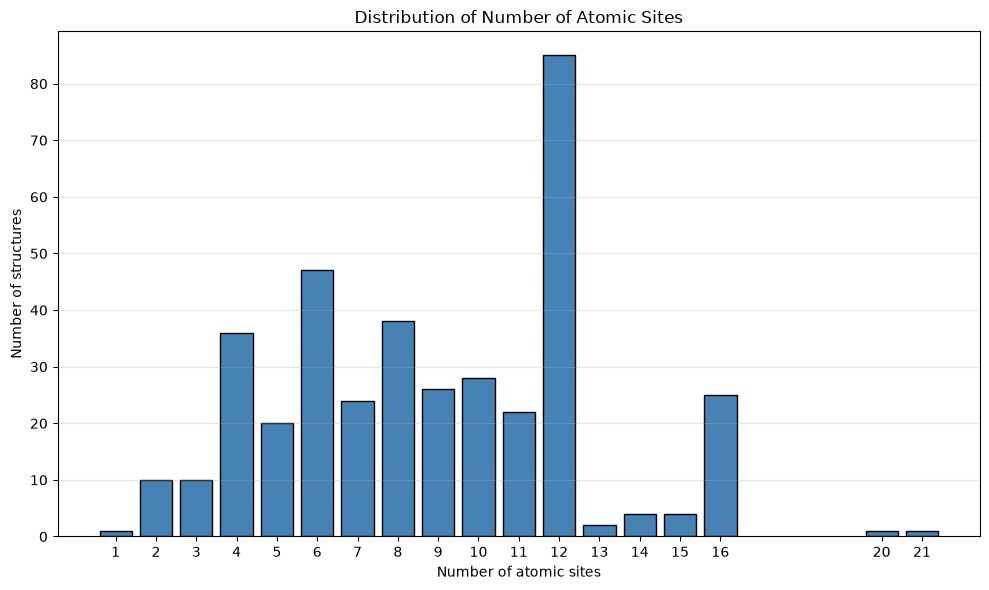

Analysing symmetry: 100%|██████████| 384/384 [00:00<00:00, 939.50it/s]


Symmetry-analysis failures: 0


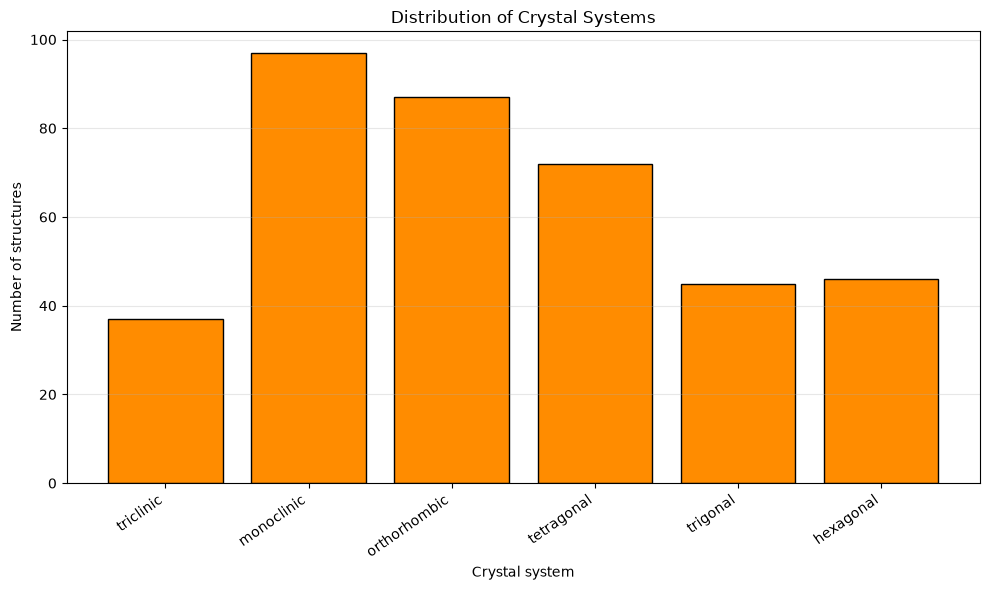

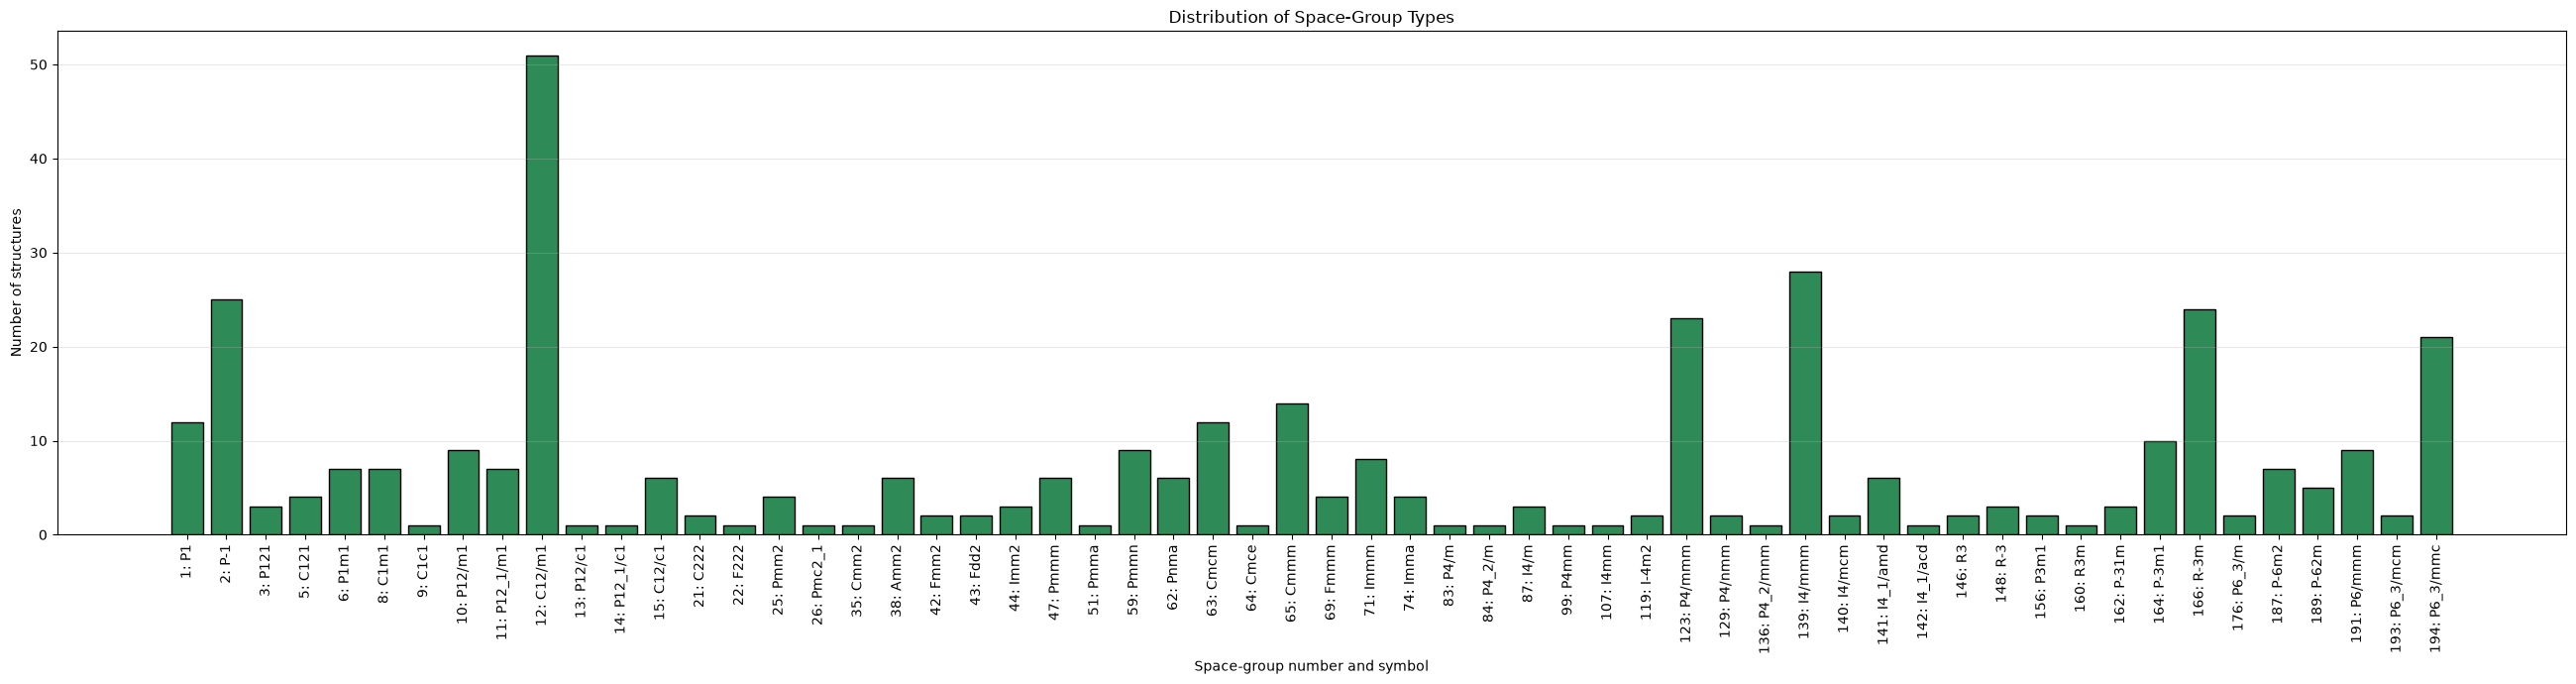

Calculating coordination numbers:   0%|          | 0/384 [00:00<?, ?it/s]/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/pymatgen/core/local_env.py:4045: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/pymatgen/core/local_env.py:4047: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/pymatgen/core/local_env.py:3959: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)
Calculating coordination numbers: 100%|██████████| 384/384 [00:22<00:00, 16.83it/s]


Coordination-number failures: 0


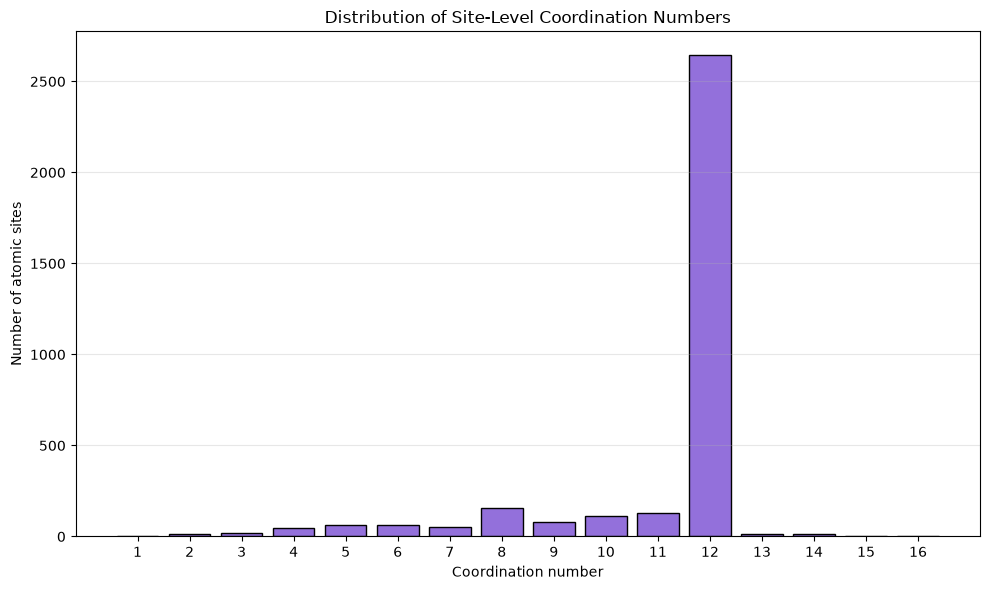


Plots saved in the figures directory:
1. figures/distribution_n_sites.png
2. figures/distribution_crystal_systems.png
3. figures/distribution_space_groups.png
4. figures/distribution_coordination_numbers.png


In [1]:
import json

import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.symmetry.groups import SpaceGroup
from pymatgen.analysis.local_env import CrystalNN

INPUT_FILE = "clean_database.json"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    clean_data = json.load(f)

structures = {sid: Structure.from_dict(s) for sid, s in clean_data["structure"].items()}
print("Number of structures:", len(structures))

def bar_plot(x, y, xlabel, ylabel, title, color, filename, rotation=0, figsize=(10, 6)):
    plt.figure(figsize=figsize)
    plt.bar(x, y, color=color, edgecolor="black")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if rotation:
        plt.xticks(rotation=rotation, ha="right" if rotation < 90 else "center")
    else:
        plt.xticks(x)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

# PLOT 1: Number of sites
site_counts = [s.num_sites for s in structures.values()]
site_dist = Counter(site_counts)
site_numbers = sorted(site_dist)
bar_plot(site_numbers, [site_dist[n] for n in site_numbers],
          "Number of atomic sites", "Number of structures",
          "Distribution of Number of Atomic Sites", "steelblue", "distribution_n_sites.png")

# Symmetry analysis
crystal_systems, space_group_numbers, symmetry_failures = [], [], []
for sid, structure in tqdm(structures.items(), desc="Analysing symmetry"):
    try:
        analyzer = SpacegroupAnalyzer(structure, symprec=0.1, angle_tolerance=5)
        crystal_systems.append(analyzer.get_crystal_system())
        space_group_numbers.append(analyzer.get_space_group_number())
    except Exception as e:
        symmetry_failures.append((sid, str(e)))

print("Symmetry-analysis failures:", len(symmetry_failures))
for f in symmetry_failures:
    print(f)

# PLOT 2: Crystal systems
cs_order = ["triclinic", "monoclinic", "orthorhombic", "tetragonal", "trigonal", "hexagonal", "cubic"]
cs_dist = Counter(crystal_systems)
present_cs = [s for s in cs_order if cs_dist[s] > 0]
bar_plot(present_cs, [cs_dist[s] for s in present_cs],
          "Crystal system", "Number of structures", "Distribution of Crystal Systems",
          "darkorange", "distribution_crystal_systems.png", rotation=35)

# PLOT 3: Space groups
sg_dist = Counter(space_group_numbers)
sg_numbers = sorted(sg_dist)
sg_labels = [f"{n}: {SpaceGroup.from_int_number(n).symbol}" for n in sg_numbers]
bar_plot(sg_labels, [sg_dist[n] for n in sg_numbers],
          "Space-group number and symbol", "Number of structures", "Distribution of Space-Group Types",
          "seagreen", "distribution_space_groups.png", rotation=90,
          figsize=(max(14, 0.45 * len(sg_labels)), 7))

# Coordination numbers
crystal_nn = CrystalNN(weighted_cn=False)
coordination_numbers, coordination_failures = [], []
for sid, structure in tqdm(structures.items(), desc="Calculating coordination numbers"):
    for i in range(structure.num_sites):
        try:
            coordination_numbers.append(int(round(crystal_nn.get_cn(structure, i))))
        except Exception as e:
            coordination_failures.append({"structure_id": sid, "site_index": i, "error": str(e)})

print("Coordination-number failures:", len(coordination_failures))
for f in coordination_failures[:10]:
    print(f)

# PLOT 4: Coordination numbers
cn_dist = Counter(coordination_numbers)
cn_numbers = sorted(cn_dist)
bar_plot(cn_numbers, [cn_dist[n] for n in cn_numbers],
          "Coordination number", "Number of atomic sites",
          "Distribution of Site-Level Coordination Numbers", "mediumpurple",
          "distribution_coordination_numbers.png")

print("\nPlots saved in the figures directory:")
for i, name in enumerate(["n_sites", "crystal_systems", "space_groups", "coordination_numbers"], 1):
    print(f"{i}. figures/distribution_{name}.png")

In [ ]:
#comment

In [2]:
import json
import numpy as np
import pandas as pd
from pymatgen.core import Structure
from matminer.featurizers.base import BaseFeaturizer, MultipleFeaturizer
from matminer.featurizers.composition import ElementFraction, ElementProperty, Stoichiometry, ValenceOrbital
from matminer.featurizers.structure import DensityFeatures, GlobalSymmetryFeatures
from matminer.featurizers.site import ChemEnvSiteFingerprint

with open("clean_database.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.index.name = "structure_id"
df["structure"] = df["structure"].apply(Structure.from_dict)
df["composition"] = df["structure"].apply(lambda s: s.composition)
print("Number of structures:", len(df))

# Composition features
comp_featurizer = MultipleFeaturizer([Stoichiometry(), ElementFraction(), ElementProperty.from_preset("magpie"), ValenceOrbital()])
comp_featurizer.set_n_jobs(1)
df = comp_featurizer.featurize_dataframe(df, col_id="composition", ignore_errors=True)

# Basic structural features
struct_featurizer = MultipleFeaturizer([DensityFeatures(), GlobalSymmetryFeatures()])
struct_featurizer.set_n_jobs(1)
df = struct_featurizer.featurize_dataframe(df, col_id="structure", ignore_errors=True)

# Custom ChemEnv statistical featurizer
class ChemEnvStats(BaseFeaturizer):
    def __init__(self):
        self.site_featurizer = ChemEnvSiteFingerprint.from_preset("simple")
        self.statistics = ("mean", "std", "min", "max")

    def featurize(self, structure):
        site_values = np.asarray([self.site_featurizer.featurize(structure, i) for i in range(len(structure))], dtype=float)
        values = []
        for fn in (np.mean, np.std, np.min, np.max):
            values.extend(fn(site_values, axis=0))
        return values

    def feature_labels(self):
        labels = self.site_featurizer.feature_labels()
        return [f"ChemEnv_{stat}_{label}" for stat in self.statistics for label in labels]

    def citations(self):
        return self.site_featurizer.citations()

    def implementors(self):
        return ["Custom ChemEnv statistical featurizer"]

chemenv_featurizer = ChemEnvStats()
chemenv_featurizer.set_n_jobs(1)
df = chemenv_featurizer.featurize_dataframe(df, col_id="structure", ignore_errors=True)

# Keep only numerical ML features (exclude k_reuss/k_voigt to avoid target leakage: k_vrh = (k_reuss + k_voigt) / 2)
non_feature_columns = ["structure", "composition", "chemsys", "n_sites", "k_reuss", "k_voigt", "k_vrh"]
X = df.drop(columns=non_feature_columns, errors="ignore")
X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=1, how="all")

feature_dataset = pd.concat([df[["chemsys"]], X, df[["k_vrh"]]], axis=1)
feature_dataset.to_csv("features.csv", index=True, index_label="structure_id")

print("\nFeature generation completed")
print("Structures:", len(feature_dataset))
print("Input features:", X.shape[1])
print("Target: k_vrh")
print("Saved as: features.csv")

/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/dscribe/core/system.py:192: SyntaxWarning: invalid escape sequence '\l'
  A_{ij} = \lvert \mathbf{r}_i - \mathbf{r}_j \\rvert
/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/dscribe/core/system.py:234: SyntaxWarning: invalid escape sequence '\l'
  A_{ij} = \\frac{1}{\lvert \mathbf{r}_i - \mathbf{r}_j \\rvert }
/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/dscribe/descriptors/acsf.py:54: SyntaxWarning: invalid escape sequence '\e'
  g2_params (n*2 np.ndarray): A list of pairs of :math:`\eta` and
/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/dscribe/descriptors/mbtr.py:212: SyntaxWarning: invalid escape sequence '\l'
  indirectly determine it through :math:`s=-\log()`:.
/home/ri52yof/projects/Bulk_Modulus_Project/.venv/lib/python3.12/site-packages/dscribe/descriptors/lmbtr.py:130: SyntaxWarning: invalid escape sequ

Number of structures: 384


ChemEnvStats: 100%|██████████| 384/384 [17:43<00:00,  2.77s/it]



Feature generation completed
Structures: 384
Input features: 515
Target: k_vrh
Saved as: features.csv


In [ ]:
#comment

In [3]:
import json
import joblib
import numpy as np
import pandas as pd
from functools import partial
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, VarianceThreshold, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline

data = pd.read_csv("features.csv", index_col="structure_id")
y = data["k_vrh"].astype(float)
X = data.drop(columns=["k_vrh", "chemsys"], errors="ignore")
X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
print("Structures:", X.shape[0])
print("Initial features:", X.shape[1])

mi_function = partial(mutual_info_regression, random_state=42)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("variance", VarianceThreshold()),
    ("selector", SelectKBest(score_func=mi_function)),
    ("model", RandomForestRegressor(random_state=42, n_jobs=1)),
])

parameter_grid = {
    "selector__k": [25, 50, 100, "all"],
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 12],
    "model__min_samples_leaf": [1, 2],
}

outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

def get_selected_feature_names(fitted_pipeline, original_names):
    names = np.asarray(original_names)
    names = names[fitted_pipeline["variance"].get_support()]
    return names[fitted_pipeline["selector"].get_support()]

fold_results, importance_results = [], []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X), start=1):
    print(f"\nRunning outer fold {fold}/5")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    search = GridSearchCV(pipeline, parameter_grid, scoring="neg_mean_absolute_error", cv=inner_cv, n_jobs=-1, refit=True)
    search.fit(X_train, y_train)

    best_pipeline = search.best_estimator_
    predictions = best_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    selected_features = get_selected_feature_names(best_pipeline, X.columns)
    feature_importances = best_pipeline["model"].feature_importances_

    fold_results.append({
        "fold": fold, "MAE": mae, "RMSE": rmse, "R2": r2,
        "inner_validation_MAE": -search.best_score_,
        "number_selected_features": len(selected_features),
        "best_parameters": json.dumps(search.best_params_),
    })

    for feature, importance in zip(selected_features, feature_importances):
        importance_results.append({"fold": fold, "feature": feature, "importance": importance})

    print("Best parameters:", search.best_params_)
    print("Selected features:", len(selected_features))
    print(f"MAE  = {mae:.4f} GPa")
    print(f"RMSE = {rmse:.4f} GPa")
    print(f"R²   = {r2:.4f}")

results_df = pd.DataFrame(fold_results)
importance_df = pd.DataFrame(importance_results)
results_df.to_csv("rf_mutual_information_nested_cv.csv", index=False)
importance_df.to_csv("rf_mutual_information_importances.csv", index=False)

print("\nNested-CV results")
print(results_df[["fold", "MAE", "RMSE", "R2", "number_selected_features"]])
print("\nMean outer-fold results")
print(results_df[["MAE", "RMSE", "R2"]].agg(["mean", "std"]))

# Train final model using the complete dataset
final_search = GridSearchCV(pipeline, parameter_grid, scoring="neg_mean_absolute_error", cv=inner_cv, n_jobs=-1, refit=True)
final_search.fit(X, y)
final_model = final_search.best_estimator_

final_selected_features = get_selected_feature_names(final_model, X.columns)
final_importances = final_model["model"].feature_importances_
final_feature_table = pd.DataFrame({
    "feature": final_selected_features, "importance": final_importances
}).sort_values("importance", ascending=False)

final_feature_table.to_csv("rf_final_selected_features.csv", index=False)
joblib.dump(final_model, "random_forest_mutual_information.joblib")
with open("rf_final_parameters.json", "w") as f:
    json.dump(final_search.best_params_, f, indent=2)

print("\nFinal Random Forest model trained")
print("Best parameters:", final_search.best_params_)
print("Number of final selected features:", len(final_selected_features))
print("\nTen most important features:")
print(final_feature_table.head(10))
print("\nSaved files:")
print("rf_mutual_information_nested_cv.csv")
print("rf_mutual_information_importances.csv")
print("rf_final_selected_features.csv")
print("rf_final_parameters.json")
print("random_forest_mutual_information.joblib")

Structures: 384
Initial features: 515

Running outer fold 1/5
Best parameters: {'model__max_depth': 12, 'model__min_samples_leaf': 2, 'model__n_estimators': 500, 'selector__k': 100}
Selected features: 100
MAE  = 4.4148 GPa
RMSE = 9.1111 GPa
R²   = 0.8930

Running outer fold 2/5
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200, 'selector__k': 25}
Selected features: 25
MAE  = 3.3480 GPa
RMSE = 6.1280 GPa
R²   = 0.9454

Running outer fold 3/5
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 500, 'selector__k': 25}
Selected features: 25
MAE  = 3.7062 GPa
RMSE = 6.3287 GPa
R²   = 0.9341

Running outer fold 4/5
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 500, 'selector__k': 100}
Selected features: 100
MAE  = 3.3206 GPa
RMSE = 8.0196 GPa
R²   = 0.9241

Running outer fold 5/5
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf

In [4]:
# ============================================================
# RANDOM FOREST + MODEL-BASED FEATURE SELECTION
# Nested CV: 5 outer folds and 5 inner folds
# ============================================================

import json
import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import (
    SelectFromModel,
    VarianceThreshold,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline


# ------------------------------------------------------------
# 1. Load features
# ------------------------------------------------------------

data = pd.read_csv(
    "features.csv",
    index_col="structure_id",
)

y = data["k_vrh"].astype(float)

X = data.drop(
    columns=["k_vrh", "chemsys"],
    errors="ignore",
)

X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)

print("Structures:", X.shape[0])
print("Initial features:", X.shape[1])


# ------------------------------------------------------------
# 2. Pipeline
# ------------------------------------------------------------

# This internal RF selects the important features
selection_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=1,
)

pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            keep_empty_features=True,
        ),
    ),
    (
        "variance",
        VarianceThreshold(),
    ),
    (
        "selector",
        SelectFromModel(
            estimator=selection_model,
            threshold=-np.inf,
        ),
    ),
    (
        "model",
        RandomForestRegressor(
            random_state=42,
            n_jobs=1,
        ),
    ),
])


# ------------------------------------------------------------
# 3. Hyperparameters
# ------------------------------------------------------------

parameter_grid = {
    # Number of features retained by SelectFromModel
    "selector__max_features": [25, 50, 100],

    # Final Random Forest hyperparameters
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 12],
    "model__min_samples_leaf": [1, 2],
}


# ------------------------------------------------------------
# 4. Inner and outer cross-validation
# ------------------------------------------------------------

outer_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

inner_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


# ------------------------------------------------------------
# Helper function for selected feature names
# ------------------------------------------------------------

def get_selected_feature_names(fitted_pipeline, original_names):

    names = np.asarray(original_names)

    # Features remaining after VarianceThreshold
    names = names[
        fitted_pipeline["variance"].get_support()
    ]

    # Features remaining after SelectFromModel
    names = names[
        fitted_pipeline["selector"].get_support()
    ]

    return names


# ------------------------------------------------------------
# 5. Nested cross-validation
# ------------------------------------------------------------

fold_results = []
importance_results = []

for fold, (train_index, test_index) in enumerate(
    outer_cv.split(X),
    start=1,
):

    print(f"\nRunning outer fold {fold}/5")

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=parameter_grid,
        scoring="neg_mean_absolute_error",
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
    )

    search.fit(X_train, y_train)

    best_pipeline = search.best_estimator_
    predictions = best_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    selected_features = get_selected_feature_names(
        best_pipeline,
        X.columns,
    )

    final_importances = best_pipeline[
        "model"
    ].feature_importances_

    fold_results.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "inner_validation_MAE": -search.best_score_,
        "number_selected_features": len(selected_features),
        "best_parameters": json.dumps(search.best_params_),
    })

    for feature, importance in zip(
        selected_features,
        final_importances,
    ):
        importance_results.append({
            "fold": fold,
            "feature": feature,
            "importance": importance,
        })

    print("Best parameters:", search.best_params_)
    print("Selected features:", len(selected_features))
    print(f"MAE  = {mae:.4f} GPa")
    print(f"RMSE = {rmse:.4f} GPa")
    print(f"R²   = {r2:.4f}")


# ------------------------------------------------------------
# 6. Save nested-CV results
# ------------------------------------------------------------

results_df = pd.DataFrame(fold_results)
importance_df = pd.DataFrame(importance_results)

results_df.to_csv(
    "rf_model_selection_nested_cv.csv",
    index=False,
)

importance_df.to_csv(
    "rf_model_selection_importances.csv",
    index=False,
)

print("\nNested-CV results:")

print(results_df[[
    "fold",
    "MAE",
    "RMSE",
    "R2",
    "number_selected_features",
]])

print("\nMean outer-fold results:")

print(
    results_df[["MAE", "RMSE", "R2"]]
    .agg(["mean", "std"])
)


# ------------------------------------------------------------
# 7. Train final model using all structures
# ------------------------------------------------------------

final_search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=inner_cv,
    n_jobs=-1,
    refit=True,
)

final_search.fit(X, y)

final_model = final_search.best_estimator_

final_selected_features = get_selected_feature_names(
    final_model,
    X.columns,
)

final_importances = final_model[
    "model"
].feature_importances_

final_feature_table = pd.DataFrame({
    "feature": final_selected_features,
    "importance": final_importances,
}).sort_values(
    "importance",
    ascending=False,
)

final_feature_table.to_csv(
    "rf_model_selection_final_features.csv",
    index=False,
)

joblib.dump(
    final_model,
    "random_forest_model_selection.joblib",
)

with open(
    "rf_model_selection_final_parameters.json",
    "w",
) as file:
    json.dump(
        final_search.best_params_,
        file,
        indent=2,
    )


print("\nFinal model trained")
print("Best parameters:", final_search.best_params_)
print(
    "Number of final selected features:",
    len(final_selected_features),
)

print("\nTen most important features:")
print(final_feature_table.head(10))

print("\nSaved files:")
print("rf_model_selection_nested_cv.csv")
print("rf_model_selection_importances.csv")
print("rf_model_selection_final_features.csv")
print("rf_model_selection_final_parameters.json")
print("random_forest_model_selection.joblib")

Structures: 384
Initial features: 515

Running outer fold 1/5
Best parameters: {'model__max_depth': 12, 'model__min_samples_leaf': 2, 'model__n_estimators': 500, 'selector__max_features': 50}
Selected features: 50
MAE  = 4.3830 GPa
RMSE = 8.3948 GPa
R²   = 0.9091

Running outer fold 2/5
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200, 'selector__max_features': 25}
Selected features: 25
MAE  = 3.4276 GPa
RMSE = 6.9859 GPa
R²   = 0.9290

Running outer fold 3/5
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 500, 'selector__max_features': 25}
Selected features: 25
MAE  = 3.8166 GPa
RMSE = 6.6034 GPa
R²   = 0.9283

Running outer fold 4/5
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 500, 'selector__max_features': 25}
Selected features: 25
MAE  = 3.8087 GPa
RMSE = 9.0221 GPa
R²   = 0.9039

Running outer fold 5/5
Best parameters: {'model__ma

In [5]:
import json
import joblib
import numpy as np
import pandas as pd
from functools import partial
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, VarianceThreshold, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline

data = pd.read_csv("features.csv", index_col="structure_id")
y = data["k_vrh"].astype(float)
X = data.drop(columns=["k_vrh", "chemsys"], errors="ignore")
X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
print("Structures:", X.shape[0])
print("Initial features:", X.shape[1])

mi_function = partial(mutual_info_regression, random_state=42, n_jobs=1)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("variance", VarianceThreshold()),
    ("selector", SelectKBest(score_func=mi_function)),
    ("model", GradientBoostingRegressor(random_state=42, min_samples_leaf=2)),
])

parameter_grid = {
    "selector__k": [25, 50, 100, "all"],
    "model__n_estimators": [100, 300],
    "model__learning_rate": [0.03, 0.10],
    "model__max_depth": [2, 3],
}

outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

def get_selected_feature_names(fitted_pipeline, original_names):
    names = np.asarray(original_names)
    names = names[fitted_pipeline["variance"].get_support()]
    return names[fitted_pipeline["selector"].get_support()]

fold_results, importance_results = [], []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X), start=1):
    print(f"\nRunning outer fold {fold}/5")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    search = GridSearchCV(pipeline, parameter_grid, scoring="neg_mean_absolute_error", cv=inner_cv, n_jobs=-1, refit=True)
    search.fit(X_train, y_train)

    best_pipeline = search.best_estimator_
    predictions = best_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    selected_features = get_selected_feature_names(best_pipeline, X.columns)
    feature_importances = best_pipeline["model"].feature_importances_

    fold_results.append({
        "fold": fold, "MAE": mae, "RMSE": rmse, "R2": r2,
        "inner_validation_MAE": -search.best_score_,
        "number_selected_features": len(selected_features),
        "best_parameters": json.dumps(search.best_params_),
    })

    for feature, importance in zip(selected_features, feature_importances):
        importance_results.append({"fold": fold, "feature": feature, "importance": importance})

    print("Best parameters:", search.best_params_)
    print("Selected features:", len(selected_features))
    print(f"MAE  = {mae:.4f} GPa")
    print(f"RMSE = {rmse:.4f} GPa")
    print(f"R²   = {r2:.4f}")

results_df = pd.DataFrame(fold_results)
importance_df = pd.DataFrame(importance_results)
results_df.to_csv("gb_mutual_information_nested_cv.csv", index=False)
importance_df.to_csv("gb_mutual_information_importances.csv", index=False)

print("\nNested-CV results:")
print(results_df[["fold", "MAE", "RMSE", "R2", "number_selected_features"]])
print("\nMean outer-fold results:")
print(results_df[["MAE", "RMSE", "R2"]].agg(["mean", "std"]))

# Train final model using the complete dataset
final_search = GridSearchCV(pipeline, parameter_grid, scoring="neg_mean_absolute_error", cv=inner_cv, n_jobs=-1, refit=True)
final_search.fit(X, y)
final_model = final_search.best_estimator_

final_selected_features = get_selected_feature_names(final_model, X.columns)
final_importances = final_model["model"].feature_importances_
final_feature_table = pd.DataFrame({
    "feature": final_selected_features, "importance": final_importances
}).sort_values("importance", ascending=False)

final_feature_table.to_csv("gb_mutual_information_final_features.csv", index=False)
joblib.dump(final_model, "gradient_boosting_mutual_information.joblib")
with open("gb_mutual_information_final_parameters.json", "w") as f:
    json.dump(final_search.best_params_, f, indent=2)

print("\nFinal Gradient Boosting model trained")
print("Best parameters:", final_search.best_params_)
print("Number of final selected features:", len(final_selected_features))
print("\nTen most important features:")
print(final_feature_table.head(10))
print("\nSaved files:")
print("gb_mutual_information_nested_cv.csv")
print("gb_mutual_information_importances.csv")
print("gb_mutual_information_final_features.csv")
print("gb_mutual_information_final_parameters.json")
print("gradient_boosting_mutual_information.joblib")

Structures: 384
Initial features: 515

Running outer fold 1/5
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 300, 'selector__k': 100}
Selected features: 100
MAE  = 4.8458 GPa
RMSE = 11.3178 GPa
R²   = 0.8348

Running outer fold 2/5
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'selector__k': 25}
Selected features: 25
MAE  = 3.9980 GPa
RMSE = 8.2748 GPa
R²   = 0.9004

Running outer fold 3/5
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'selector__k': 100}
Selected features: 100
MAE  = 4.0610 GPa
RMSE = 7.6011 GPa
R²   = 0.9050

Running outer fold 4/5
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 300, 'selector__k': 100}
Selected features: 100
MAE  = 3.5595 GPa
RMSE = 7.9351 GPa
R²   = 0.9257

Running outer fold 5/5
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n

In [6]:
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline

data = pd.read_csv("features.csv", index_col="structure_id")
y = data["k_vrh"].astype(float)
X = data.drop(columns=["k_vrh", "chemsys"], errors="ignore")
X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
print("Structures:", X.shape[0])
print("Initial features:", X.shape[1])

# Internal Random Forest used only for feature selection
selection_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("variance", VarianceThreshold()),
    ("selector", SelectFromModel(estimator=selection_model, threshold=-np.inf)),
    ("model", GradientBoostingRegressor(random_state=42, min_samples_leaf=2)),
])

parameter_grid = {
    "selector__max_features": [25, 50, 100],
    "model__n_estimators": [100, 300],
    "model__learning_rate": [0.03, 0.10],
    "model__max_depth": [2, 3],
}

outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

def get_selected_feature_names(fitted_pipeline, original_names):
    names = np.asarray(original_names)
    names = names[fitted_pipeline["variance"].get_support()]
    return names[fitted_pipeline["selector"].get_support()]

fold_results, importance_results = [], []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X), start=1):
    print(f"\nRunning outer fold {fold}/5")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    search = GridSearchCV(pipeline, parameter_grid, scoring="neg_mean_absolute_error", cv=inner_cv, n_jobs=-1, refit=True)
    search.fit(X_train, y_train)

    best_pipeline = search.best_estimator_
    predictions = best_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    selected_features = get_selected_feature_names(best_pipeline, X.columns)
    feature_importances = best_pipeline["model"].feature_importances_

    fold_results.append({
        "fold": fold, "MAE": mae, "RMSE": rmse, "R2": r2,
        "inner_validation_MAE": -search.best_score_,
        "number_selected_features": len(selected_features),
        "best_parameters": json.dumps(search.best_params_),
    })

    for feature, importance in zip(selected_features, feature_importances):
        importance_results.append({"fold": fold, "feature": feature, "importance": importance})

    print("Best parameters:", search.best_params_)
    print("Selected features:", len(selected_features))
    print(f"MAE  = {mae:.4f} GPa")
    print(f"RMSE = {rmse:.4f} GPa")
    print(f"R²   = {r2:.4f}")

results_df = pd.DataFrame(fold_results)
importance_df = pd.DataFrame(importance_results)
results_df.to_csv("gb_model_selection_nested_cv.csv", index=False)
importance_df.to_csv("gb_model_selection_importances.csv", index=False)

print("\nNested-CV results:")
print(results_df[["fold", "MAE", "RMSE", "R2", "number_selected_features"]])
print("\nMean outer-fold results:")
print(results_df[["MAE", "RMSE", "R2"]].agg(["mean", "std"]))

# Train final model using all structures
final_search = GridSearchCV(pipeline, parameter_grid, scoring="neg_mean_absolute_error", cv=inner_cv, n_jobs=-1, refit=True)
final_search.fit(X, y)
final_model = final_search.best_estimator_

final_selected_features = get_selected_feature_names(final_model, X.columns)
final_importances = final_model["model"].feature_importances_
final_feature_table = pd.DataFrame({
    "feature": final_selected_features, "importance": final_importances
}).sort_values("importance", ascending=False)

final_feature_table.to_csv("gb_model_selection_final_features.csv", index=False)
joblib.dump(final_model, "gradient_boosting_model_selection.joblib")
with open("gb_model_selection_final_parameters.json", "w") as f:
    json.dump(final_search.best_params_, f, indent=2)

print("\nFinal Gradient Boosting model trained")
print("Best parameters:", final_search.best_params_)
print("Number of final selected features:", len(final_selected_features))
print("\nTen most important features:")
print(final_feature_table.head(10))
print("\nSaved files:")
print("gb_model_selection_nested_cv.csv")
print("gb_model_selection_importances.csv")
print("gb_model_selection_final_features.csv")
print("gb_model_selection_final_parameters.json")
print("gradient_boosting_model_selection.joblib")

Structures: 384
Initial features: 515

Running outer fold 1/5
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'selector__max_features': 25}
Selected features: 25
MAE  = 4.7972 GPa
RMSE = 10.7251 GPa
R²   = 0.8517

Running outer fold 2/5
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'selector__max_features': 25}
Selected features: 25
MAE  = 3.1120 GPa
RMSE = 6.7372 GPa
R²   = 0.9340

Running outer fold 3/5
Best parameters: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 300, 'selector__max_features': 25}
Selected features: 25
MAE  = 3.5622 GPa
RMSE = 5.5236 GPa
R²   = 0.9498

Running outer fold 4/5
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 300, 'selector__max_features': 100}
Selected features: 100
MAE  = 3.4263 GPa
RMSE = 7.9745 GPa
R²   = 0.9249

Running outer fold 5/5
Best parameters: {'model__learning_rat

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
configuration,,,,,,
GB + Model Selection,4.0684,1.0009,10.0555,5.5251,0.8694,0.1089
GB + Mutual Information,4.4208,0.8241,10.8789,4.9175,0.8508,0.0971
RF + Model Selection,4.2201,0.8765,10.0754,5.2900,0.8710,0.1047
RF + Mutual Information,4.0625,0.9280,9.7766,5.4622,0.8768,0.1077


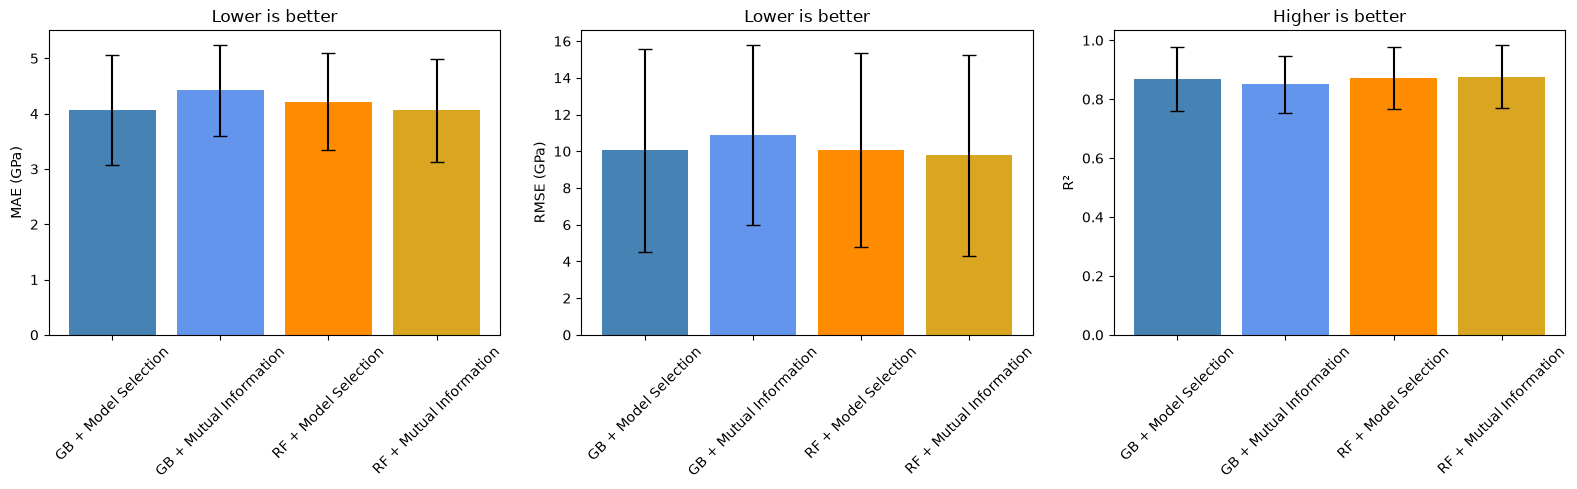

Best configuration: RF + Mutual Information
Mean MAE: 4.0625 GPa

Saved files:
all_model_fold_results.csv
model_comparison_summary.csv
model_comparison.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

result_files = {
    "RF + Mutual Information": "rf_mutual_information_nested_cv.csv",
    "RF + Model Selection": "rf_model_selection_nested_cv.csv",
    "GB + Mutual Information": "gb_mutual_information_nested_cv.csv",
    "GB + Model Selection": "gb_model_selection_nested_cv.csv",
}

all_results = []
for model_name, filename in result_files.items():
    result = pd.read_csv(filename)
    result["configuration"] = model_name
    all_results.append(result)

combined_results = pd.concat(all_results, ignore_index=True)
combined_results.to_csv("all_model_fold_results.csv", index=False)

summary = combined_results.groupby("configuration")[["MAE", "RMSE", "R2"]].agg(["mean", "std"])
summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
summary = summary.round(4)
summary.to_csv("model_comparison_summary.csv")
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [("MAE", "MAE (GPa)", "Lower is better"), ("RMSE", "RMSE (GPa)", "Lower is better"), ("R2", "R²", "Higher is better")]
colors = ["steelblue", "cornflowerblue", "darkorange", "goldenrod"]

for axis, (metric, ylabel, title) in zip(axes, metrics):
    axis.bar(summary.index, summary[f"{metric}_mean"], yerr=summary[f"{metric}_std"], capsize=5, color=colors)
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

best_model = summary["MAE_mean"].idxmin()
print("Best configuration:", best_model)
print("Mean MAE:", summary.loc[best_model, "MAE_mean"], "GPa")
print("\nSaved files:")
print("all_model_fold_results.csv")
print("model_comparison_summary.csv")
print("model_comparison.png")